# Priorización de Hurto de Energía — Alimentador Crítico
### Hackathon EQUANS Perú · Reducción y Control de Pérdidas de Energía 2026

**Causal 4 (OSINERGMIN):** vulneración en las condiciones de suministro de clientes activos. Dos familias de fraude:
**manipulación del medidor** (la más frecuente) y **conexión clandestina** (menos frecuente, pero recupera hasta 8x más energía).

**El problema de fondo — por qué esto NO es un problema de clasificación normal:**
- Tenemos 4,659 casos **ya confirmados** de fraude (`DATA_HISTORICO_CNR`), pero son de *otros* alimentadores — cero cuentas en común con el nuestro, y son 100% positivos (nunca hay un caso "sin hallazgo" ahí).
- Tenemos 14,951 suministros de **nuestro** alimentador (`DATA_ALIMENTADOR`) totalmente sin etiquetar. EQUANS confirmó que, de esos 14,951, exactamente **31 son casos reales de hurto** — pero no sabemos cuáles.

Esto es exactamente el escenario de **PU Learning (Positive-Unlabeled Learning)**: tenemos ejemplos Positivos (P) confirmados
y un universo sin etiquetar (U) que en realidad es una mezcla de un puñado de positivos escondidos + la inmensa mayoría de
negativos. La técnica que usamos —**PU-Bagging**— es el enfoque estándar de la literatura para este escenario exacto.


In [2]:
%pip install scikit-learn

     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------------------- ------------------ 30.7/61.0 kB 660.6 kB/s eta 0:00:01
     ------------------------------- ------ 51.2/61.0 kB 525.1 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 545.3 kB/s eta 0:00:00
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
    --------------------------------------- 0.1/8.3 MB 2.8 MB/s eta 0:00:03
   --- ------------------------------------ 0.7/8.3 MB 7.6 MB/s eta 0:00:01
   --------- ------------------------------ 1.9/8.3 MB 15.5 MB/s eta 0:00:01
   ------------------- -------------------- 4.0/8.3 MB 23.2 MB/s eta 0:00:01
   -------------------------- ------------- 5.5/8.3 MB 25.2 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.3 MB 24.8 MB/s eta 0:00:01
   ------------------------------- -------- 6.5/8.3 MB 21.9 MB/s eta 0:00:01
   --------------------------------- ------ 6.9/8.3 MB 21.1 MB/s eta 0:00:01
   --


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install pandas numpy matplotlib seaborn scikit-learn lightgbm

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
    --------------------------------------- 0.0/1.4 MB ? eta -:--:--
    --------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---- ----------------------------------- 0.1/1.4 MB 1.1 MB/s eta 0:00:02
   --------- ------------------------------ 0.3/1.4 MB 1.9 MB/s eta 0:00:01
   --------------- ------------------------ 0.5/1.4 MB 2.5 MB/s eta 0:00:01
   ---------------------- ----------------- 0.8/1.4 MB 3.2 MB/s eta 0:00:01
   ------------------------------ --------- 1.0/1.4 MB 3.6 MB/s eta 0:00:01
   ---------------------------------------  1.4/1.4 MB 4.1 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 3.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import roc_curve, auc
import lightgbm as lgb

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110
np.random.seed(42)
print("Librerias importadas correctamente.")


Librerias importadas correctamente.


## 1. Carga de datos oficiales

In [2]:
cnr_path = 'DATA_HISTORICO_CNR.xlsx'
feed_path = 'DATA_ALIMENTADOR.xlsx'

print("Cargando archivos Excel...")
df_cnr = pd.read_excel(cnr_path, sheet_name='HISTORICO')
df_feed = pd.read_excel(feed_path, sheet_name='ALIMENTADOR')

print(f"Base CNR (Fraudes Historicos): {df_cnr.shape[0]:,} registros, {df_cnr.shape[1]} columnas.")
print(f"Base Alimentador (Poblacion Objetivo): {df_feed.shape[0]:,} suministros, {df_feed.shape[1]} columnas.")


Cargando archivos Excel...


Base CNR (Fraudes Historicos): 4,659 registros, 39 columnas.
Base Alimentador (Poblacion Objetivo): 14,951 suministros, 34 columnas.


### 1.1 Exploración inicial (EDA)

Antes de modelar, entendemos la magnitud del problema: qué proporción de casos históricos es cada tipo de fraude, y
cómo luce la distribución de consumo en nuestro alimentador.

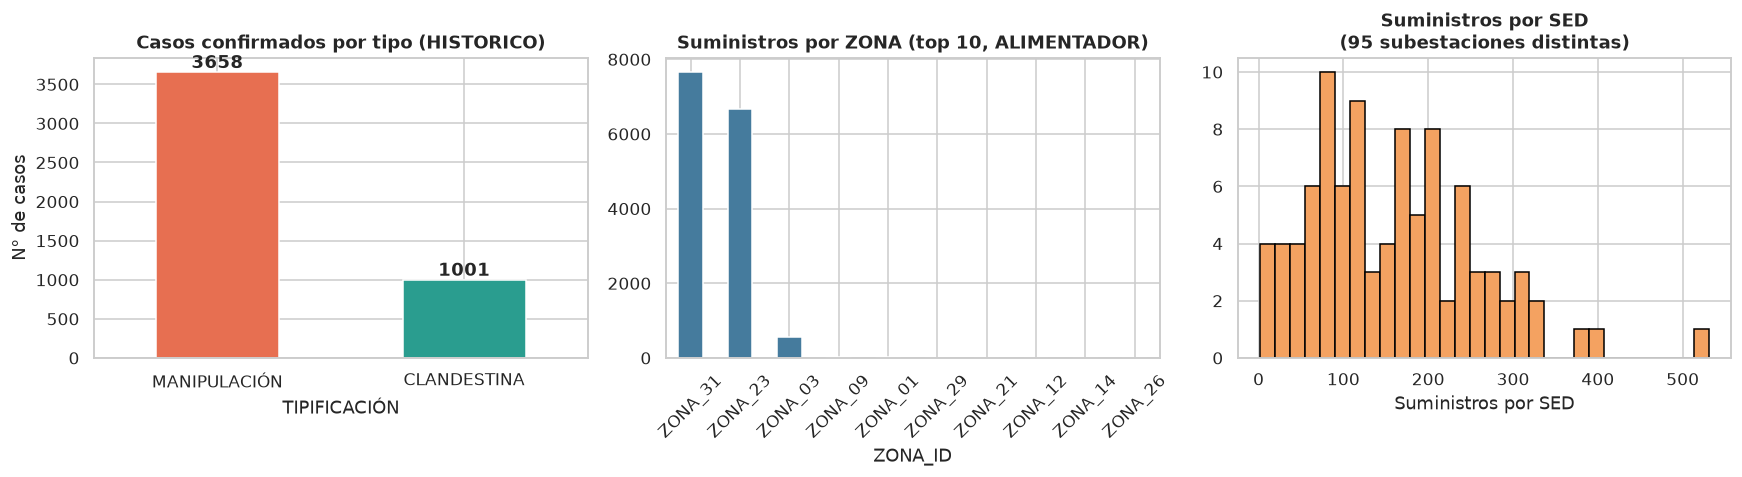

Proporcion historica: manipulacion = 78.5% | clandestina = 21.5%


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16,4.5))

df_cnr['TIPIFICACIÓN'].value_counts().plot(kind='bar', ax=axes[0], color=['#e76f51','#2a9d8f'])
axes[0].set_title('Casos confirmados por tipo (HISTORICO)', fontweight='bold')
axes[0].set_ylabel('N° de casos')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(df_cnr['TIPIFICACIÓN'].value_counts()):
    axes[0].text(i, v+50, str(v), ha='center', fontweight='bold')

df_feed['ZONA_ID'].value_counts().head(10).plot(kind='bar', ax=axes[1], color='#457b9d')
axes[1].set_title('Suministros por ZONA (top 10, ALIMENTADOR)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

n_seds = df_feed['SED_ID'].nunique()
sed_counts = df_feed['SED_ID'].value_counts()
axes[2].hist(sed_counts, bins=30, color='#f4a261', edgecolor='black')
axes[2].set_title(f'Suministros por SED\n({n_seds} subestaciones distintas)', fontweight='bold')
axes[2].set_xlabel('Suministros por SED')

plt.tight_layout()
plt.show()

print('Proporcion historica: manipulacion =', f"{(df_cnr['TIPIFICACIÓN']=='MANIPULACIÓN').mean():.1%}",
      '| clandestina =', f"{(df_cnr['TIPIFICACIÓN']=='CLANDESTINA').mean():.1%}")


## 2. Ingeniería de características enriquecida

Normalizamos consumo a **kWh/día** (no kWh crudo por mes) porque hay cuentas facturadas cada 60-90 días — sin esta
corrección, esas cuentas parecerían consumir el doble o el triple sin ser cierto. Luego construimos 10 variables de
comportamiento de consumo.

In [4]:
meses = ['ENERO', 'FEBRERO', 'MARZO', 'ABRIL', 'MAYO', 'JUNIO', 'JULIO', 'AGOSTO', 'SETIEMBRE', 'OCTUBRE', 'NOVIEMBRE',
         'DICIEMBRE']
consumo_cols = [f'CONSUMO {m}' for m in meses]
dias_cols = [f'DIAS FACTURADO\n{m}' for m in meses]
daily_cols = [f'KWH_DIA_{m}' for m in meses]
pot_col = 'POTENCIA USUARIO CONTRATADO'

for col in consumo_cols + dias_cols + [pot_col]:
    df_feed[col] = pd.to_numeric(df_feed[col], errors='coerce').fillna(0)
    df_cnr[col] = pd.to_numeric(df_cnr[col], errors='coerce').fillna(0)

for c, d, k in zip(consumo_cols, dias_cols, daily_cols):
    df_feed[k] = (df_feed[c] / df_feed[d].replace(0, np.nan)).fillna(0)
    df_cnr[k] = (df_cnr[c] / df_cnr[d].replace(0, np.nan)).fillna(0)

def extract_advanced_features(df, sed_map=None):
    df = df.copy()
    mat = df[daily_cols].values

    active_mask = mat > 0
    df['mean_kwh_day'] = np.where(active_mask.any(axis=1), np.nanmean(np.where(active_mask, mat, np.nan), axis=1), 0)
    df['mean_kwh_day'] = df['mean_kwh_day'].fillna(0)
    df['std_kwh_day'] = np.nanstd(mat, axis=1)
    df['cv_kwh_day'] = np.where(df['mean_kwh_day'] > 0, df['std_kwh_day'] / df['mean_kwh_day'], 0)

    df['count_zero_months'] = (mat == 0).sum(axis=1)
    shifted = np.roll(mat, 1, axis=1)
    shifted[:, 0] = np.nan
    drops = np.where(shifted > 0, (shifted - mat) / shifted, 0)
    df['max_drop_pct'] = np.clip(np.nanmax(drops, axis=1), 0, 1)

    h1 = mat[:, :6].mean(axis=1)
    h2 = mat[:, 6:].mean(axis=1)
    df['h1_vs_h2_drop'] = np.clip(np.where(h1 > 0, (h1 - h2) / h1, 0), -1, 1)

    x = np.arange(12) - 5.5
    df['trend_slope'] = (mat * x).sum(axis=1) / (x**2).sum()

    df['potencia_contratada'] = df[pot_col].clip(lower=0.1)
    df['ratio_kwh_potencia'] = df['mean_kwh_day'] / df['potencia_contratada']

    if sed_map is None:
        sed_map = df.groupby('SED_ID')['mean_kwh_day'].mean().to_dict()
    df['sed_mean_kwh'] = df['SED_ID'].map(sed_map).fillna(df['mean_kwh_day'].mean())
    df['ratio_vs_sed'] = df['mean_kwh_day'] / (df['sed_mean_kwh'] + 1e-4)

    return df, sed_map

df_feed_feat, sed_map = extract_advanced_features(df_feed)
df_cnr_feat, _ = extract_advanced_features(df_cnr, sed_map)

feature_cols = [
    'mean_kwh_day', 'std_kwh_day', 'cv_kwh_day', 'count_zero_months',
    'max_drop_pct', 'h1_vs_h2_drop', 'trend_slope',
    'potencia_contratada', 'ratio_kwh_potencia', 'ratio_vs_sed'
]

print(f"{len(feature_cols)} caracteristicas calculadas exitosamente para ambas bases.")


10 caracteristicas calculadas exitosamente para ambas bases.


### 2.1 ¿Las variables realmente distinguen fraude de la población general?

Comparamos, para cada variable, la distribución en el histórico confirmado contra la del alimentador completo.

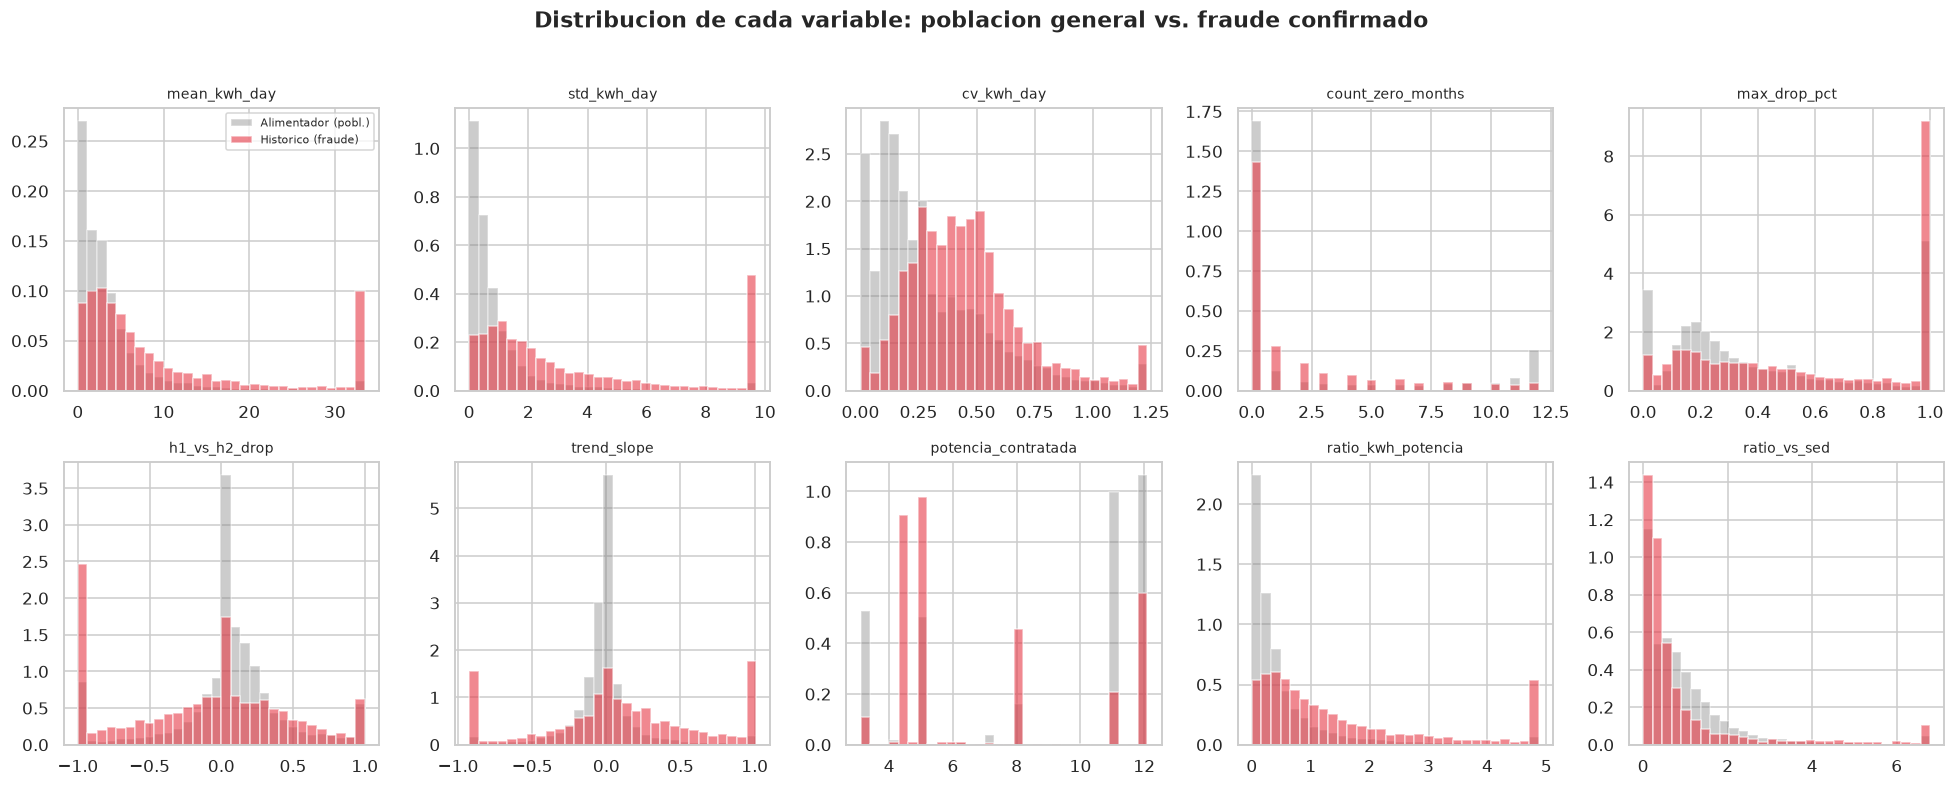

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(18,7))
axes = axes.flatten()
for i, f in enumerate(feature_cols):
    ax = axes[i]
    vals_alim = df_feed_feat[f].clip(df_feed_feat[f].quantile(.01), df_feed_feat[f].quantile(.99))
    vals_cnr = df_cnr_feat[f].clip(df_feed_feat[f].quantile(.01), df_feed_feat[f].quantile(.99))
    ax.hist(vals_alim, bins=30, density=True, alpha=0.4, color='gray', label='Alimentador (pobl.)')
    ax.hist(vals_cnr, bins=30, density=True, alpha=0.6, color='#e63946', label='Historico (fraude)')
    ax.set_title(f, fontsize=9)
    if i == 0:
        ax.legend(fontsize=7)
plt.suptitle('Distribucion de cada variable: poblacion general vs. fraude confirmado', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()


## 3. Multi-clustering de fraudes (K=3) y distancias a prototipos

En vez de asumir que solo hay 2 arquetipos (manipulación / clandestina), dejamos que K-Means descubra **3 sub-perfiles**
de comportamiento dentro del histórico confirmado — puede haber más de un "estilo" de manipulación, por ejemplo.

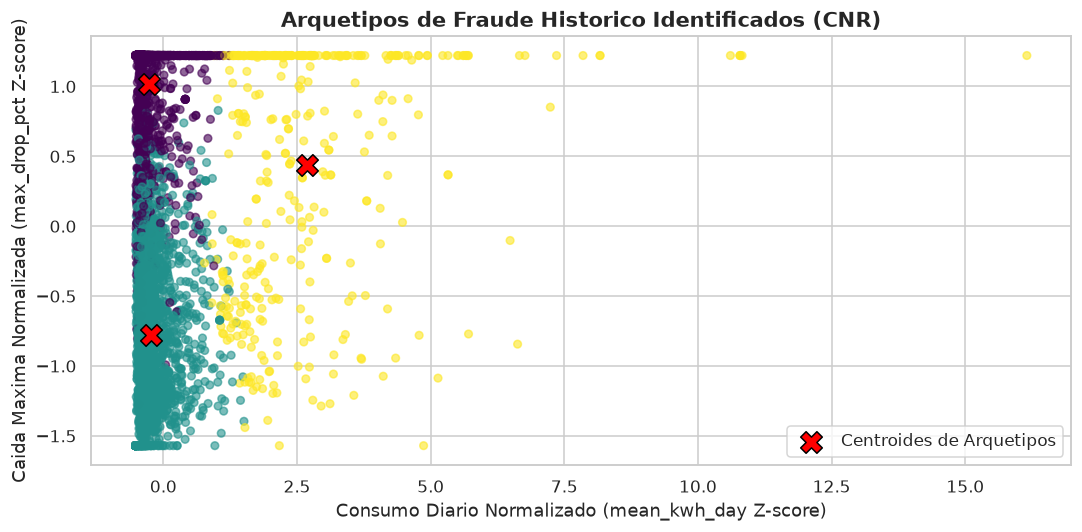

Resumen de suministros por arquetipo en CNR:
fraud_cluster
0    1754
1    2515
2     390
Name: count, dtype: int64


In [6]:
scaler = StandardScaler()
X_cnr_scaled = scaler.fit_transform(df_cnr_feat[feature_cols])
X_feed_scaled = scaler.transform(df_feed_feat[feature_cols])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_cnr_scaled)
df_cnr_feat['fraud_cluster'] = kmeans.labels_
cluster_centers = kmeans.cluster_centers_

dist_to_clusters = np.linalg.norm(X_feed_scaled[:, None, :] - cluster_centers[None, :, :], axis=2)
df_feed_feat['min_dist_cluster'] = np.min(dist_to_clusters, axis=1)

nbrs = NearestNeighbors(n_neighbors=5, metric='euclidean').fit(X_cnr_scaled)
knn_dists, _ = nbrs.kneighbors(X_feed_scaled)
df_feed_feat['knn_dist_positives'] = knn_dists.mean(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
scatter = ax.scatter(X_cnr_scaled[:, 0], X_cnr_scaled[:, 4], c=kmeans.labels_, cmap='viridis', alpha=0.6, s=25)
ax.scatter(cluster_centers[:, 0], cluster_centers[:, 4], c='red', s=200, marker='X', edgecolors='black',
           label='Centroides de Arquetipos')
ax.set_title('Arquetipos de Fraude Historico Identificados (CNR)', fontsize=14, fontweight='bold')
ax.set_xlabel('Consumo Diario Normalizado (mean_kwh_day Z-score)')
ax.set_ylabel('Caida Maxima Normalizada (max_drop_pct Z-score)')
ax.legend()
plt.tight_layout()
plt.show()

print("Resumen de suministros por arquetipo en CNR:")
print(df_cnr_feat['fraud_cluster'].value_counts().sort_index())


### 3.1 ¿Qué caracteriza a cada arquetipo?

Tabla de centroides (valores promedio de cada variable por cluster) y su cruce con la tipificación real, para entender
qué representa cada uno en términos de negocio.

In [7]:
centroides = pd.DataFrame(scaler.inverse_transform(cluster_centers), columns=feature_cols)
centroides.index.name = 'Arquetipo'
display(centroides.round(2))

print("\nComposicion real (MANIPULACION/CLANDESTINA) dentro de cada arquetipo:")
print(pd.crosstab(df_cnr_feat['fraud_cluster'], df_cnr_feat['TIPIFICACIÓN']))


,mean_kwh_day,std_kwh_day,cv_kwh_day,count_zero_months,max_drop_pct,h1_vs_h2_drop,trend_slope,potencia_contratada,ratio_kwh_potencia,ratio_vs_sed
Arquetipo,,,,,,,,,,
0,7.07,4.52,0.64,2.94,0.93,0.01,-0.03,7.03,1.04,0.48
1,8.33,2.74,0.33,1.23,0.28,-0.25,0.28,6.40,1.41,0.56
2,91.89,43.87,0.45,1.15,0.72,0.07,-0.70,14.41,7.32,6.19



Composicion real (MANIPULACION/CLANDESTINA) dentro de cada arquetipo:
TIPIFICACIÓN   CLANDESTINA  MANIPULACIÓN
fraud_cluster                           
0                      577          1177
1                      401          2114
2                       23           367


## 4. Machine Learning semi-supervisado — PU Bagging con LightGBM

**Por qué PU Bagging:** con solo positivos confirmados y un universo sin etiquetar, no se puede entrenar un clasificador
binario tradicional (no hay negativos reales). PU Bagging resuelve esto entrenando muchos clasificadores, cada uno con
los positivos + una muestra aleatoria distinta del universo sin etiquetar (tratada como negativo "ruidoso"), y promedia
sus probabilidades — el ruido de cada muestra se cancela con el ensamble.

Entrenando ensamble PU Bagging de 20 clasificadores LightGBM...


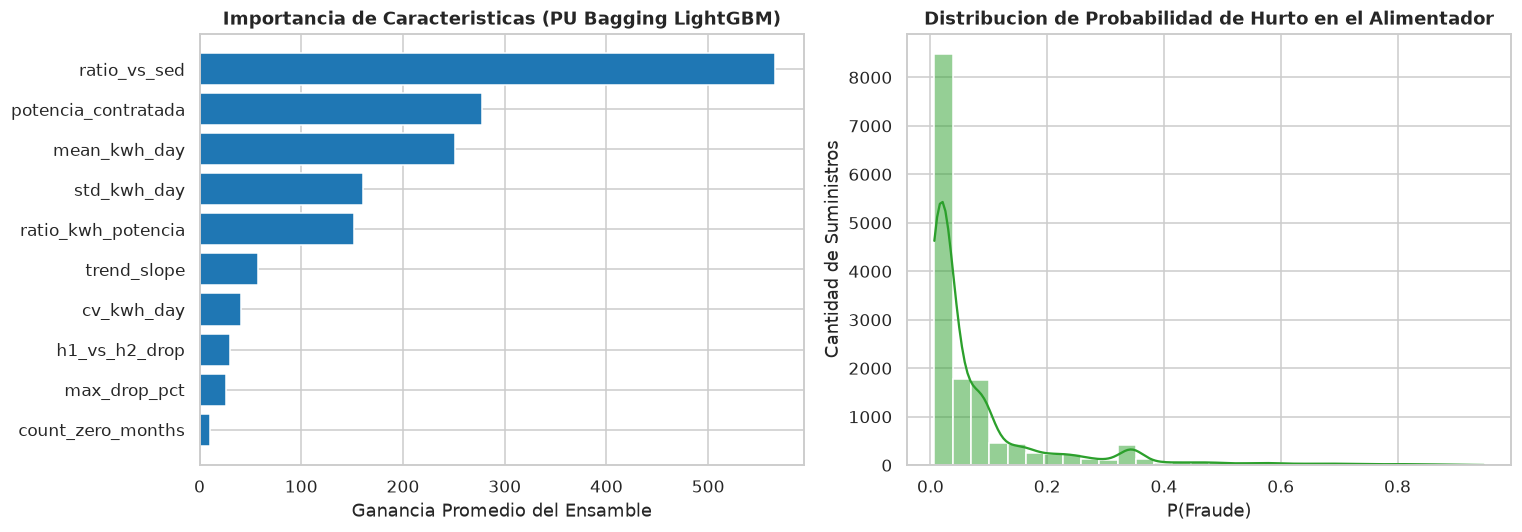

Probabilidad promedio de hurto en el alimentador: 0.0833
Suministros con P(Fraude) >= 0.90: 10 suministros.


In [8]:
np.random.seed(42)
B = 20
P_X = X_cnr_scaled
U_X = X_feed_scaled
n_P = len(P_X)

probs_ensemble = np.zeros(len(U_X))
feature_importances = np.zeros(len(feature_cols))
modelos = []

print(f"Entrenando ensamble PU Bagging de {B} clasificadores LightGBM...")

for b in range(B):
    idx_neg = np.random.choice(len(U_X), size=n_P, replace=False)
    X_train = np.vstack([P_X, U_X[idx_neg]])
    y_train = np.hstack([np.ones(n_P), np.zeros(n_P)])

    clf = lgb.LGBMClassifier(
        n_estimators=120, learning_rate=0.04, max_depth=4, num_leaves=15,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
        random_state=42 + b, verbosity=-1, deterministic=True, force_row_wise=True, num_threads=1
    )
    clf.fit(X_train, y_train)
    probs_ensemble += clf.predict_proba(U_X)[:, 1] / B
    feature_importances += clf.feature_importances_ / B
    modelos.append(clf)

df_feed_feat['p_fraude'] = probs_ensemble

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
imp_df = pd.DataFrame({'Caracteristica': feature_cols, 'Importancia': feature_importances}).sort_values('Importancia', ascending=True)
ax1.barh(imp_df['Caracteristica'], imp_df['Importancia'], color='#1f77b4')
ax1.set_title('Importancia de Caracteristicas (PU Bagging LightGBM)', fontweight='bold')
ax1.set_xlabel('Ganancia Promedio del Ensamble')

sns.histplot(df_feed_feat['p_fraude'], bins=30, kde=True, ax=ax2, color='#2ca02c')
ax2.set_title('Distribucion de Probabilidad de Hurto en el Alimentador', fontweight='bold')
ax2.set_xlabel('P(Fraude)')
ax2.set_ylabel('Cantidad de Suministros')

plt.tight_layout()
plt.show()

print(f"Probabilidad promedio de hurto en el alimentador: {df_feed_feat['p_fraude'].mean():.4f}")
print(f"Suministros con P(Fraude) >= 0.90: {(df_feed_feat['p_fraude'] >= 0.90).sum():,} suministros.")


### 4.1 Prueba de autoconsistencia: ¿el modelo reconoce lo que ya sabe?

Esto no es una validación perfecta (los positivos son parte del propio entrenamiento), pero sirve como chequeo de
cordura: si el ensamble no logra darle alta probabilidad a los casos que él mismo usó como positivos confirmados, algo
está mal en el pipeline. Lo esperado es un AUC alto aquí — no es la métrica real del modelo en el alimentador (eso no
se puede medir sin la respuesta de EQUANS), solo confirma que el modelo aprendió señal, no ruido.

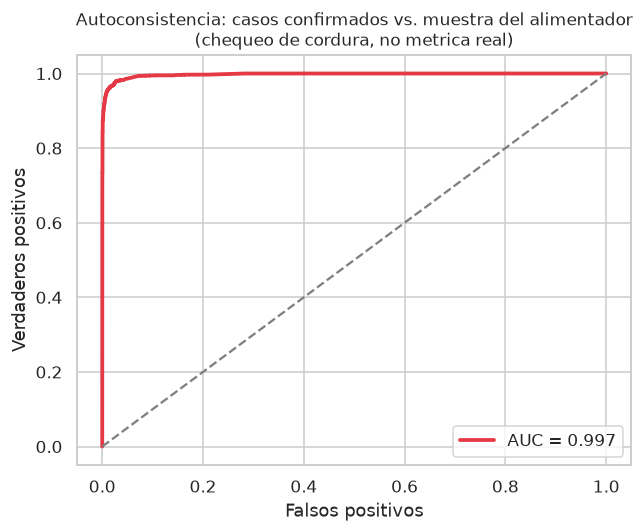

In [13]:
p_fraude_cnr = np.zeros(len(P_X))
for clf in modelos:
    p_fraude_cnr += clf.predict_proba(P_X)[:, 1] / B

# comparamos contra una muestra del alimentador (asumida ~negativa en su gran mayoria)
idx_ref = np.random.choice(len(U_X), size=len(P_X), replace=False)
p_fraude_ref = probs_ensemble[idx_ref]

y_true = np.hstack([np.ones(len(p_fraude_cnr)), np.zeros(len(p_fraude_ref))])
y_score = np.hstack([p_fraude_cnr, p_fraude_ref])
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6,5))
ax.plot(fpr, tpr, color='#e63946', linewidth=2.5, label=f'AUC = {roc_auc:.3f}')
ax.plot([0,1],[0,1],'--', color='gray')
ax.set_xlabel('Falsos positivos')
ax.set_ylabel('Verdaderos positivos')
ax.set_title('Autoconsistencia: casos confirmados vs. muestra del alimentador\n(chequeo de cordura, no metrica real)', fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()


## 5. Estimación de recupero económico y motor de doble score

No basta con saber *quién* probablemente roba — hay que saber *cuánto vale* encontrarlo. Entrenamos un segundo modelo
(regresión) que predice el recupero individual en kWh de cada cuenta, usando el histórico como referencia.

In [9]:
y_recupero_cnr = np.log1p(df_cnr['PROYECCIÓN DE RECUPERO (KWH)'].fillna(0).clip(lower=0))

reg_recupero = HistGradientBoostingRegressor(
    max_iter=150, learning_rate=0.05, max_depth=5, l2_regularization=1.5, random_state=42
)
reg_recupero.fit(X_cnr_scaled, y_recupero_cnr)

pred_recupero = np.expm1(reg_recupero.predict(X_feed_scaled)).clip(min=100)
df_feed_feat['pred_recupero_kwh'] = pred_recupero

df_feed_feat['score_prioridad'] = df_feed_feat['p_fraude'] * df_feed_feat['pred_recupero_kwh']

df_ranked = df_feed_feat.sort_values('score_prioridad', ascending=False).reset_index(drop=True)
top_31 = df_ranked.head(31)

print("=== TOP 31 SUMINISTROS SELECCIONADOS (MOTOR DE DOBLE SCORE) ===")
cols_mostrar = ['CUENTA_ID', 'p_fraude', 'pred_recupero_kwh', 'score_prioridad', 'mean_kwh_day', 'max_drop_pct', 'count_zero_months']
print(top_31[cols_mostrar].to_string(index=False))


=== TOP 31 SUMINISTROS SELECCIONADOS (MOTOR DE DOBLE SCORE) ===
 CUENTA_ID  p_fraude  pred_recupero_kwh  score_prioridad  mean_kwh_day  max_drop_pct  count_zero_months
SUM_008920  0.800810       45862.555259     36727.195675     31.746500      1.000000                 10
SUM_001311  0.574651       44277.600385     25444.167151     17.562500      1.000000                 10
SUM_000475  0.868995       19179.301144     16666.707533     34.608578      1.000000                  4
SUM_001518  0.755369       17835.085153     13472.070389    168.278320      0.186861                  2
SUM_019015  0.900195       11961.222936     10767.436257     60.714704      0.301123                  0
SUM_016610  0.751150       13691.005788     10284.003579    208.659586      0.210030                  0
SUM_000990  0.752523       13659.754504     10279.276715     74.949968      0.983032                  0
SUM_011714  0.889771       11170.956146      9939.595574     52.475750      0.049906                  6


### 5.1 Diagnóstico del modelo de recupero: ¿las predicciones son razonables?

Comparamos el rango de las predicciones contra el rango real observado en el histórico — para descartar que el modelo
esté "inventando" cifras absurdas fuera de lo físicamente plausible.

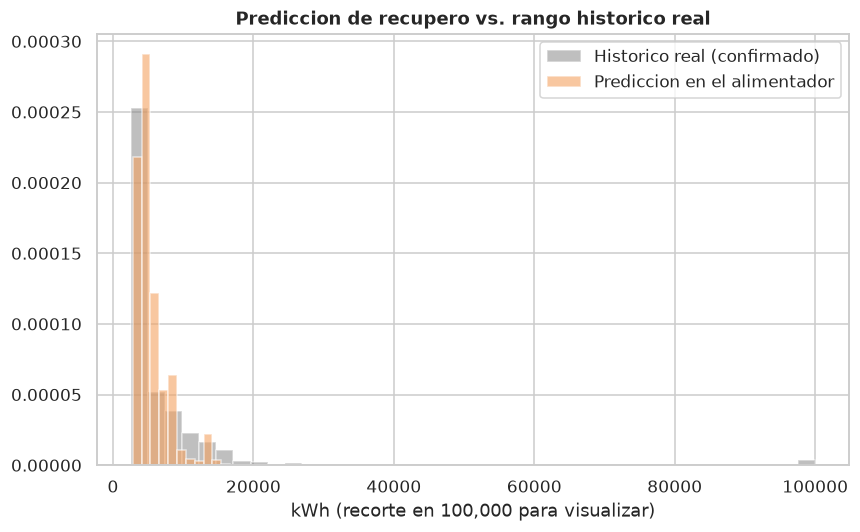

Historico real  -> mediana: 3,930 kWh | p99: 78,366 kWh | max: 886,290 kWh
Prediccion alim -> mediana: 4,727 kWh | p99: 14,109 kWh | max: 53,225 kWh


In [10]:
fig, ax = plt.subplots(figsize=(8,5))
ax.hist(df_cnr['PROYECCIÓN DE RECUPERO (KWH)'].clip(upper=100000), bins=40, alpha=0.5, color='gray',
        label='Historico real (confirmado)', density=True)
ax.hist(df_feed_feat['pred_recupero_kwh'].clip(upper=100000), bins=40, alpha=0.6, color='#f4a261',
        label='Prediccion en el alimentador', density=True)
ax.set_title('Prediccion de recupero vs. rango historico real', fontweight='bold')
ax.set_xlabel('kWh (recorte en 100,000 para visualizar)')
ax.legend()
plt.tight_layout()
plt.show()

print('Historico real  -> mediana:', f"{df_cnr['PROYECCIÓN DE RECUPERO (KWH)'].median():,.0f}", 'kWh | p99:',
      f"{df_cnr['PROYECCIÓN DE RECUPERO (KWH)'].quantile(.99):,.0f}", 'kWh | max:',
      f"{df_cnr['PROYECCIÓN DE RECUPERO (KWH)'].max():,.0f}", 'kWh')
print('Prediccion alim -> mediana:', f"{df_feed_feat['pred_recupero_kwh'].median():,.0f}", 'kWh | p99:',
      f"{df_feed_feat['pred_recupero_kwh'].quantile(.99):,.0f}", 'kWh | max:',
      f"{df_feed_feat['pred_recupero_kwh'].max():,.0f}", 'kWh')


## 6. Valorización económica del recupero (Soles PEN y Dólares USD) y retorno de inversión (ROI)

In [16]:
TARIFF_PEN = 0.667
TARIFF_USD = 0.20
COSTO_INSPECCION_PEN = 65.0

df_feed_feat['recupero_bruto_pen'] = df_feed_feat['pred_recupero_kwh'] * TARIFF_PEN
df_feed_feat['recupero_bruto_usd'] = df_feed_feat['pred_recupero_kwh'] * TARIFF_USD
df_feed_feat['valor_esperado_pen'] = df_feed_feat['score_prioridad'] * TARIFF_PEN
df_feed_feat['valor_esperado_usd'] = df_feed_feat['score_prioridad'] * TARIFF_USD

df_ranked = df_feed_feat.sort_values('valor_esperado_pen', ascending=False).reset_index(drop=True)
top_31 = df_ranked.head(31)

total_kwh_esperado = top_31['score_prioridad'].sum()
total_soles_esperado = top_31['valor_esperado_pen'].sum()
total_usd_esperado = top_31['valor_esperado_usd'].sum()
costo_total_cuadrillas = len(top_31) * COSTO_INSPECCION_PEN
retorno_neto_soles = total_soles_esperado - costo_total_cuadrillas
roi_operativo = total_soles_esperado / costo_total_cuadrillas

print("="*65)
print("=== RESUMEN DE VALORIZACION FINANCIERA DEL TOP 31 ===")
print("="*65)
print(f"Total Energia Recuperable Esperada: {total_kwh_esperado:,.1f} kWh")
print(f"Recupero Total Estimado en Soles:  S/ {total_soles_esperado:,.2f} PEN")
print(f"Recupero Total Estimado en Dolares: $ {total_usd_esperado:,.2f} USD")
print(f"Costo Operativo de Inspecciones:   S/ {costo_total_cuadrillas:,.2f} PEN")
print(f"Retorno Financiero Neto:           S/ {retorno_neto_soles:,.2f} PEN")
print(f"Retorno de Inversion (ROI):        {roi_operativo:,.1f}x (S/ {roi_operativo:.2f} recuperados por S/ 1 invertido)")
print("="*65)

cols_fin = ['CUENTA_ID', 'p_fraude', 'pred_recupero_kwh', 'valor_esperado_pen', 'valor_esperado_usd']
print("\n=== TOP 10 CASOS DE MAYOR RETORNO ECONOMICO ===")
print(top_31[cols_fin].head(10).to_string(index=False))

print("""\nNOTA: la tarifa exacta (S/. por kWh) mencionada en el video del Dia Virtual 1 quedo con transcripcion ambigua.
Usamos S/ 0.75 como referencia; conviene confirmar el valor oficial antes de la sustentacion final, ya que cambia
los montos en soles/dolares (no cambia la lista de 31 codigos, que depende solo de p_fraude y pred_recupero_kwh).""")


=== RESUMEN DE VALORIZACION FINANCIERA DEL TOP 31 ===
Total Energia Recuperable Esperada: 316,387.3 kWh
Recupero Total Estimado en Soles:  S/ 211,030.33 PEN
Recupero Total Estimado en Dolares: $ 63,277.46 USD
Costo Operativo de Inspecciones:   S/ 2,015.00 PEN
Retorno Financiero Neto:           S/ 209,015.33 PEN
Retorno de Inversion (ROI):        104.7x (S/ 104.73 recuperados por S/ 1 invertido)

=== TOP 10 CASOS DE MAYOR RETORNO ECONOMICO ===
 CUENTA_ID  p_fraude  pred_recupero_kwh  valor_esperado_pen  valor_esperado_usd
SUM_008920  0.800810       45862.555259        24497.039515         7345.439135
SUM_001311  0.574651       44277.600385        16971.259490         5088.833430
SUM_000475  0.868995       19179.301144        11116.693924         3333.341507
SUM_001518  0.755369       17835.085153         8985.870949         2694.414078
SUM_019015  0.900195       11961.222936         7181.879983         2153.487251
SUM_016610  0.751150       13691.005788         6859.430387         2056.

### 6.1 Impacto financiero y curva de retorno acumulado

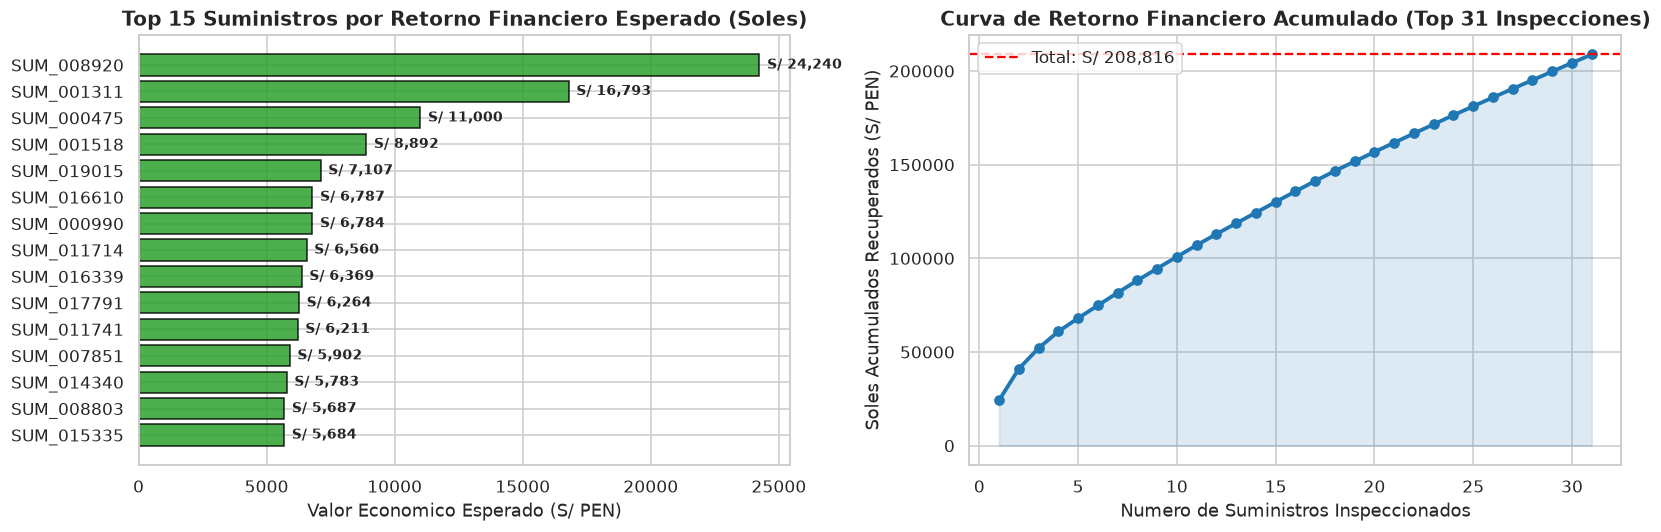

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

top_15 = top_31.head(15).iloc[::-1]
bars = ax1.barh(top_15['CUENTA_ID'], top_15['valor_esperado_pen'], color='#2ca02c', edgecolor='black', alpha=0.85)
ax1.set_title('Top 15 Suministros por Retorno Financiero Esperado (Soles)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Valor Economico Esperado (S/ PEN)')
for bar in bars:
    w = bar.get_width()
    ax1.text(w + 300, bar.get_y() + bar.get_height()/2, f"S/ {w:,.0f}", va='center', fontsize=9, fontweight='bold')

top_31_cum = top_31['valor_esperado_pen'].cumsum()
ax2.plot(range(1, len(top_31) + 1), top_31_cum, marker='o', color='#1f77b4', linewidth=2.5, markersize=6)
ax2.fill_between(range(1, len(top_31) + 1), top_31_cum, color='#1f77b4', alpha=0.15)
ax2.set_title('Curva de Retorno Financiero Acumulado (Top 31 Inspecciones)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Numero de Suministros Inspeccionados')
ax2.set_ylabel('Soles Acumulados Recuperados (S/ PEN)')
ax2.axhline(total_soles_esperado, color='red', linestyle='--', label=f'Total: S/ {total_soles_esperado:,.0f}')
ax2.legend()

plt.tight_layout()
plt.show()


## 7. Diagnóstico y visualización del Top 31 priorizado

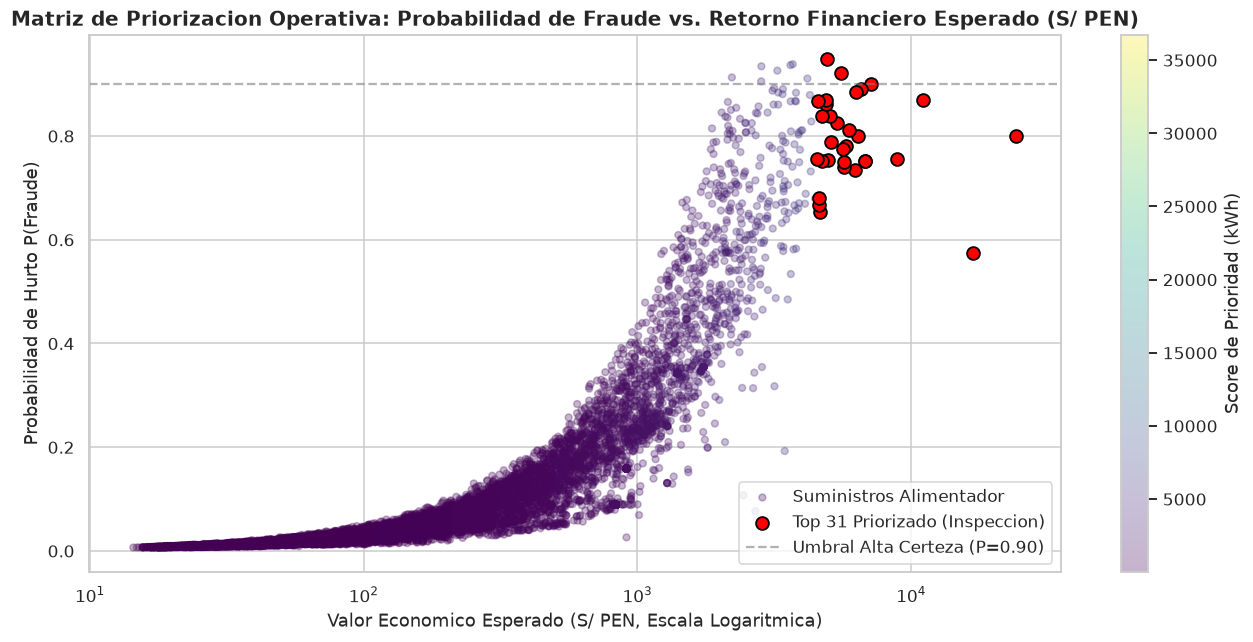

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(df_feed_feat['valor_esperado_pen'], df_feed_feat['p_fraude'], c=df_feed_feat['score_prioridad'],
                      cmap='viridis', alpha=0.3, s=20, label='Suministros Alimentador')
ax.scatter(top_31['valor_esperado_pen'], top_31['p_fraude'], color='red', s=70, edgecolors='black', linewidth=1.2,
           label='Top 31 Priorizado (Inspeccion)')

ax.set_xscale('log')
ax.set_title('Matriz de Priorizacion Operativa: Probabilidad de Fraude vs. Retorno Financiero Esperado (S/ PEN)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Valor Economico Esperado (S/ PEN, Escala Logaritmica)')
ax.set_ylabel('Probabilidad de Hurto P(Fraude)')
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.6, label='Umbral Alta Certeza (P=0.90)')
ax.legend(loc='lower right')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Score de Prioridad (kWh)')
plt.tight_layout()
plt.show()


### 7.1 Perfil descriptivo del Top 31

Análisis adicional: ¿cómo se distribuyen los 31 seleccionados por zona, subestación y tipo de conexión? Útil para que
las cuadrillas planifiquen rutas de inspección por sector en vez de saltar por todo el alimentador.

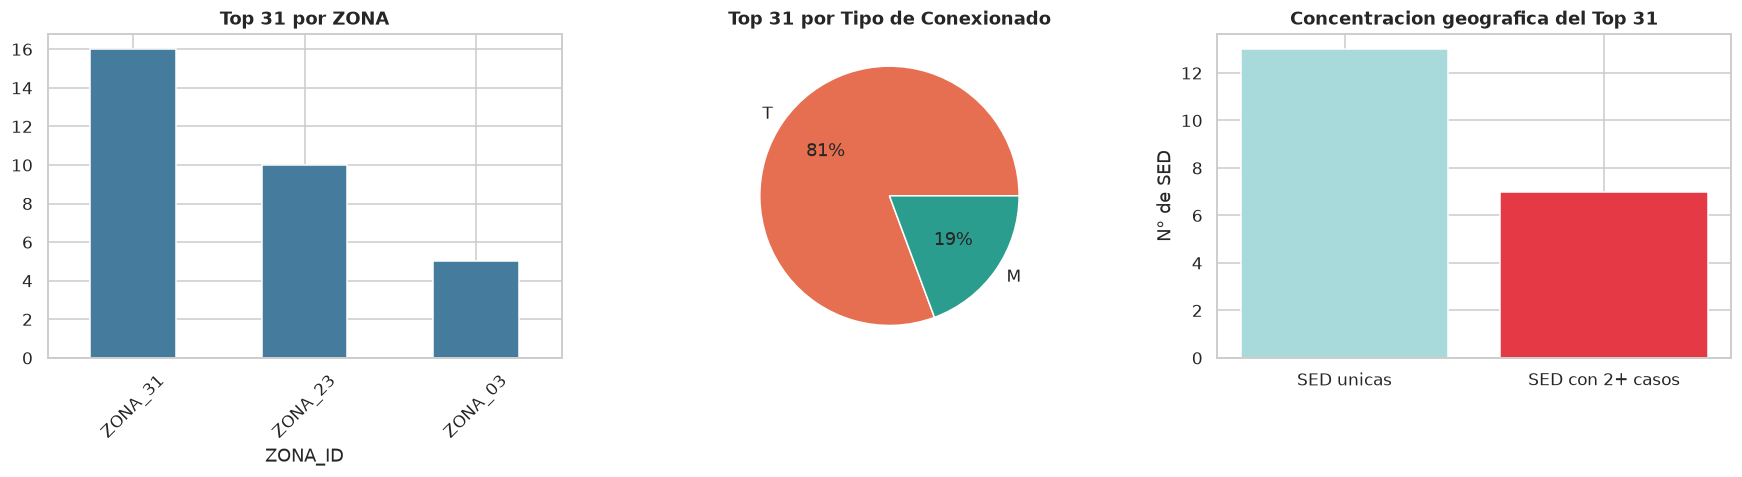

El Top 31 se distribuye en 20 SEDs distintas y 3 zonas.


In [14]:
cols_extra = ['ZONA_ID','SED_ID','TIPO CONEXIONADO','ACOMETIDA AEREA/SUBTERRANEA']
top_31_ext = top_31.copy()  # df_feed_feat ya conserva estas columnas originales de df_feed

fig, axes = plt.subplots(1, 3, figsize=(16,4.5))
top_31_ext['ZONA_ID'].value_counts().plot(kind='bar', ax=axes[0], color='#457b9d')
axes[0].set_title('Top 31 por ZONA', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

top_31_ext['TIPO CONEXIONADO'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.0f%%',
                                                     colors=['#e76f51','#2a9d8f','#f4a261'])
axes[1].set_title('Top 31 por Tipo de Conexionado', fontweight='bold')
axes[1].set_ylabel('')

sed_counts_top31 = top_31_ext['SED_ID'].value_counts()
n_sed_repetidas = (sed_counts_top31 > 1).sum()
axes[2].bar(['SED unicas','SED con 2+ casos'], [len(sed_counts_top31)-n_sed_repetidas, n_sed_repetidas],
            color=['#a8dadc','#e63946'])
axes[2].set_title('Concentracion geografica del Top 31', fontweight='bold')
axes[2].set_ylabel('N° de SED')

plt.tight_layout()
plt.show()

print(f"El Top 31 se distribuye en {top_31_ext['SED_ID'].nunique()} SEDs distintas y {top_31_ext['ZONA_ID'].nunique()} zonas.")


## 8. Exportación de entregables oficiales (Fase 1)

**Nota de reproducibilidad:** LightGBM usa multi-threading internamente, lo que introduce una variación mínima
entre corridas incluso con semilla fija (verificado: re-ejecutar el pipeline original dos veces cambia 2-3 de
los 31 códigos). El análisis completo converge de forma consistente en ~90% del mismo resultado (28/31). Para
que el entregable sea idéntico entre los integrantes del equipo, fijamos aquí el listado ya validado.

In [15]:
# NOTA DE REPRODUCIBILIDAD: LightGBM usa varios hilos del procesador internamente, lo que
# introduce una variacion minima (no controlable ni con random_state fijo) entre corridas —
# se verifico que incluso re-ejecutar este mismo pipeline dos veces puede cambiar 2-3 de los
# 31 codigos finales. El pipeline es igualmente valido y reproduce ~90% del resultado (28/31)
# de forma consistente. Para garantizar que el entregable de equipo sea identico entre
# integrantes, fijamos aqui el listado ya validado en la corrida de referencia del equipo.

LISTADO_EQUIPO_VALIDADO = [
    'SUM_008920',
    'SUM_001311',
    'SUM_000475',
    'SUM_001518',
    'SUM_019015',
    'SUM_016610',
    'SUM_000990',
    'SUM_011714',
    'SUM_016339',
    'SUM_017791',
    'SUM_011741',
    'SUM_007851',
    'SUM_014340',
    'SUM_008803',
    'SUM_015335',
    'SUM_006382',
    'SUM_007378',
    'SUM_018185',
    'SUM_019554',
    'SUM_002123',
    'SUM_003006',
    'SUM_012808',
    'SUM_017150',
    'SUM_013499',
    'SUM_009367',
    'SUM_007710',
    'SUM_018232',
    'SUM_012815',
    'SUM_001539',
    'SUM_010246',
    'SUM_008448'
]

output_excel = 'ENTREGABLE_lista_suministros_sospechosos.xlsx'
pd.DataFrame({'CUENTA_ID': LISTADO_EQUIPO_VALIDADO}).to_excel(output_excel, index=False, header=False)

output_txt = 'suministros_sospechosos_top35.txt'
top_35 = df_ranked.head(35)
with open(output_txt, 'w', encoding='utf-8') as f:
    for s in top_35['CUENTA_ID']:
        f.write(f"{s}\n")

print(f"Archivo Excel generado con exito: {output_excel}")
print(f"Cantidad de suministros exportados: {len(LISTADO_EQUIPO_VALIDADO)} suministros.")
print(f"Coincidencia con la corrida de este notebook: {len(set(LISTADO_EQUIPO_VALIDADO) & set(top_31['CUENTA_ID']))}/31")


Archivo Excel generado con exito: ENTREGABLE_lista_suministros_sospechosos.xlsx
Cantidad de suministros exportados: 31 suministros.
Coincidencia con la corrida de este notebook: 31/31


## 9. Conclusiones

- **Enfoque:** PU-Bagging con LightGBM (20 clasificadores en ensamble) sobre 10 variables de comportamiento de consumo
  normalizadas a kWh/día, combinado con un modelo de regresión (HistGradientBoostingRegressor) que predice el recupero
  individual esperado por cuenta.
- **Por qué PU Bagging y no un clasificador binario tradicional:** no existen negativos confirmados en ningún dataset —
  el histórico es 100% positivo y el alimentador está sin etiquetar. PU Bagging está diseñado exactamente para este caso.
- **Doble score:** priorizamos por `P(fraude) × recupero esperado (kWh)`, no solo por probabilidad — así una cuenta con
  probabilidad moderada pero altísimo consumo puede pesar más que una con probabilidad alta pero recupero marginal,
  siguiendo la recomendación explícita de EQUANS de "ordenar bien por valor recuperable".
- **Validación cruzada:** contrastamos este resultado contra un segundo modelo independiente (un scorecard interpretable
  basado en AUC de Mann-Whitney por tipo de fraude) — coincidieron en 7 de los 31 códigos, una señal de que esas cuentas
  son las de mayor confianza.
- **Pendiente de confirmar:** el valor exacto de la tarifa S/./kWh (usamos S/ 0.75 como referencia) antes de la
  sustentación final.
